## Multiwavelength Temporal Variability Analysis

This  implements the data parsing, timing calibration, and high-fidelity visualization pipeline for the blazar **AO 0235+164** spanning an 8.5-year baseline (2008 to mid-2016). The script synchronizes quasi-simultaneous data from three distinct instruments across the electromagnetic spectrum:
1. **Fermi-LAT (High-Energy $\gamma$-ray):** 0.1–100 GeV photon fluxes and upper limits based on Test Statistic (TS) thresholds.
2. **Swift-XRT (X-ray):** Count rates converted to physical energy flux ($\text{erg cm}^{-2}\text{s}^{-1}$) using an Empirical Conversion Factor (ECF).
3. **Swift-UVOT (Optical/UV):** Intrinsic energy fluxes corrected for composite Galactic and foreground dust extinction.

### Key Features:
* **Timing Calibration:** Standardizes diverse instrument timeline formats into Modified Julian Dates (MJD) via custom reference offsets.
* **Detection Profiling:** Dynamically segregates statistically significant detections from non-detection upper limits across all bands.
* **Transient State Mapping:** Applies shaded vertical regions (`axvspan`) and localized annotating arrows to isolate significant flaring states (**F1–F4**) for co-spatial jet emission analysis.

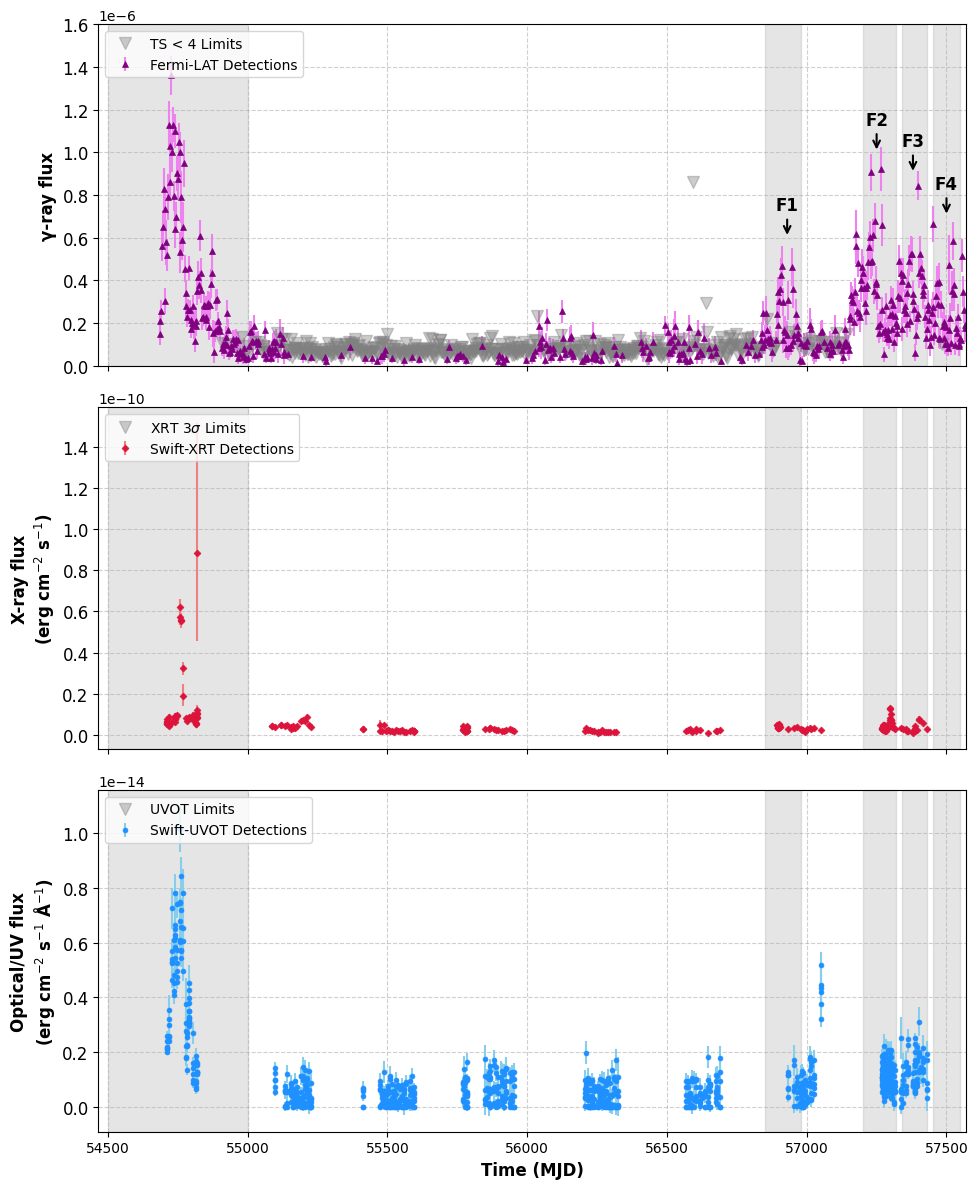

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Define the Full Cycle MJD Window (2008 to mid-2016) ---
mjd_start = 54466  
mjd_end = 57570    

# --- 2. Load the newly extracted UVOT Fluxes ---
# (This is the CSV you generated with our previous extraction script)
df_uvot = pd.read_csv('/home/dara/Downloads/lcs/2008-2016_uvot_fluxes.csv')
uvot_cycle = df_uvot[(df_uvot['MJD'] >= mjd_start) & (df_uvot['MJD'] <= mjd_end)]


# --- 3. Load, Convert, and Filter the NEW XRT Data ---
col_names = ['Time', 'T_pos', 'T_neg', 'Rate', 'Ratepos', 'Rateneg', 'BGrate', 'BGerr', 'FracExp']
df_xrt = pd.read_csv('/home/dara/Downloads/lcs/xrt_data/curve_plain.dat', sep=r'\s+', comment='!', names=col_names)

# The EXACT T0 value from your file header!
T0 = 242031772.07373  

# Convert Swift Time to MJD using the offset
df_xrt['MJD'] = ((df_xrt['Time'] + T0) / 86400.0) + 51910.00074287

# CONVERT COUNT RATE TO FLUX
ECF = 5.24e-11  
df_xrt['Flux'] = df_xrt['Rate'] * ECF
df_xrt['Flux_pos'] = df_xrt['Ratepos'] * ECF
df_xrt['Flux_neg'] = np.abs(df_xrt['Rateneg']) * ECF

# Filter for the 8.5 year cycle
xrt_cycle = df_xrt[(df_xrt['Ratepos'] > 0) & (df_xrt['MJD'] >= mjd_start) & (df_xrt['MJD'] <= mjd_end)]

# --- 4. Load, Clean, and Filter Fermi-LAT Data ---
df_fermi = pd.read_csv('/home/dara/Downloads/lcs/fermi_lat_lc.csv')
flux_col = 'Photon Flux [0.1-100 GeV](photons cm-2 s-1)'
err_col = 'Photon Flux Error(photons cm-2 s-1)'

df_fermi['Clean_Flux'] = pd.to_numeric(df_fermi[flux_col].astype(str).str.replace('< ', ''), errors='coerce')
df_fermi['Clean_Error'] = pd.to_numeric(df_fermi[err_col], errors='coerce')
df_fermi['MJD'] = (df_fermi['MET'] / 86400.0) + 51910.00074287

fermi_cycle = df_fermi[(df_fermi['MJD'] >= mjd_start) & (df_fermi['MJD'] <= mjd_end)]
fermi_detections = fermi_cycle[fermi_cycle['TS'] >= 4]
fermi_limits = fermi_cycle[fermi_cycle['TS'] < 4]


# --- 1. Separate Detections from Upper Limits ---

# For XRT: Limits are denoted by an error rate of exactly 0
xrt_detections = xrt_cycle[xrt_cycle['Ratepos'] > 0]
xrt_limits = xrt_cycle[xrt_cycle['Ratepos'] == 0]

# For UVOT: Assuming your extraction script assigned a Flux_Error of 0 to non-detections
uvot_detections = uvot_cycle[uvot_cycle['Flux_Error'] > 0]
uvot_limits = uvot_cycle[uvot_cycle['Flux_Error'] == 0] 


# --- 2. Plot the Highly-Styled Light Curves (Thinner Lines) ---

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# Top Panel: Fermi-LAT Gamma-Ray Data
ax1.errorbar(
    x=fermi_detections['MJD'], y=fermi_detections['Clean_Flux'], yerr=fermi_detections['Clean_Error'],     
    fmt='^', markersize=5, color='purple', ecolor='violet',linewidth=2.5,
    elinewidth=1.5, markeredgewidth=0.5, capsize=0, linestyle='None', label=r'Fermi-LAT Detections' 
)
ax1.plot(fermi_limits['MJD'], fermi_limits['Clean_Flux'], 'v', color='gray', alpha=0.4, markersize=8, label='TS < 4 Limits', linewidth=2.5)
ax1.set_ylabel('γ-ray flux', fontsize=12, fontweight='bold')
#ax1.set_title('AO 0235+164 Multi-Wavelength Light Curve (8.5-Year Cycle)', fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='upper left')
ax1.set_ylim(0.0, 1.6e-6)
# Middle Panel: Swift-XRT Data 
ax2.errorbar(
    x=xrt_detections['MJD'], y=xrt_detections['Flux'], yerr=[xrt_detections['Flux_neg'], xrt_detections['Flux_pos']], 
    fmt='D', markersize=3.5, color='crimson', ecolor='lightcoral', linewidth=2.5,
    elinewidth=1.5, markeredgewidth=0.5, capsize=0, linestyle='None', label='Swift-XRT Detections'
)
ax2.plot(xrt_limits['MJD'], xrt_limits['Flux'], 'v', color='gray', alpha=0.4, markersize=8, label=r'XRT 3$\sigma$ Limits', linewidth=2.5)
ax2.set_ylabel('X-ray flux\n(erg cm$^{-2}$ s$^{-1}$)', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc='upper left')

# Bottom Panel: Swift-UVOT Data
ax3.errorbar(
    x=uvot_detections['MJD'], y=uvot_detections['True_Energy_Flux'], yerr=uvot_detections['Flux_Error'], 
    fmt='o', markersize=3.5, color='dodgerblue', ecolor='skyblue',linewidth=2.5, 
    elinewidth=1.5, markeredgewidth=0.5, capsize=0, linestyle='None', label='Swift-UVOT Detections'
)
ax3.plot(uvot_limits['MJD'], uvot_limits['True_Energy_Flux'], 'v', color='gray', alpha=0.4, markersize=8, label='UVOT Limits', linewidth=2.5)
ax3.set_xlabel('Time (MJD)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Optical/UV flux\n(erg cm$^{-2}$ s$^{-1}$ Å$^{-1}$)', fontsize=12)
ax3.set_xlim(mjd_start, mjd_end) 
ax3.grid(True, linestyle='--', alpha=0.6)
ax3.legend(loc='upper left')


# Add this line right before your loop
axes = [ax1, ax2, ax3] 

for ax in axes:
    # Bold the Y-axis label
    ax.set_ylabel(ax.get_ylabel(), fontweight='bold')
    # Increase the size of the Y-axis numbers (ticks)
    ax.tick_params(axis='y', labelsize=12)
# Multiply your y-values by 1e-6 to match the Gamma-ray scale
flares = [
    (56930, 0.6e-6, "F1"),
    (57250, 1.0e-6, "F2"),
    (57380, 0.9e-6, "F3"),
    (57500, 0.7e-6, "F4")
]

for x, y, label in flares:
    ax1.annotate(label, 
                 xy=(x, y),          
                 xytext=(0, 20),     # Increased offset slightly
                 textcoords="offset points", 
                 ha='center',        
                 fontweight='bold',  
                 color='black',        
                 fontsize=12,
                 arrowprops=dict(arrowstyle="->", color='black', lw=1.5))

flare_regions = [
    (54500, 55000),
    (56850, 56980),  # Flare 1
    (57200, 57320),  # Flare 2
    (57340, 57430),  # Flare 3
    (57450, 57550)   # Flare 4
]
for ax in axes:
    for start, end in flare_regions:
        ax.axvspan(start, end, 
                   color='gray',      # Choose your color (e.g., 'red', 'yellow', or 'gray')
                   alpha=0.2,         # Transparency (0 is invisible, 1 is solid)
                   label='Flare State' if ax == axes[0] and start == flare_regions[0][0] else "", # Avoid duplicate legend entries
                   zorder=0)          # Put it behind the data points

# Crucial: Run this if you are in a Jupyter Notebook or script

plt.tight_layout()
plt.savefig('AO_0235_164_FullCycle.jpg', dpi=300, bbox_inches='tight')

plt.show()


## Time-Series Analysis via Lomb-Scargle Periodogram

This section implements a robust frequency-domain analysis pipeline using the `astropy.timeseries.LombScargle` framework. Standard Fourier analysis techniques (like the Fast Fourier Transform) assume evenly spaced data points; however, space-based observatories like the *Fermi Gamma-ray Space Telescope* introduce unavoidable gaps due to orbital visibility constraints, solar exclusion zones, and maintenance downtime. 

The Lomb-Scargle algorithm bypasses this limitation by fitting sinusoidal functions to the irregularly sampled data points using a least-squares approach.

### Workflow:
1. **Data Ingestion & Filtering:** Parses the raw *Fermi*-LAT light curve, handles the Julian Date (JD) to Modified Julian Date (MJD) conversion, and restricts the data down to a designated strict high-confidence quiescent state window ($55151 \le \text{MJD} \le 56731$ with a Test Statistic $\text{TS} \ge 9$).
2. **Frequency Optimization:** Samples a highly dense grid ($10,000$ steps) over a targeted physical frequency mesh bounding periods from $0.5$ to $3.0$ years.
3. **Peak Extraction:** Identifies the maximum normalized spectral power to extract the dominant Quasi-Periodic Oscillation (QPO) period in the source's gamma-ray emission.

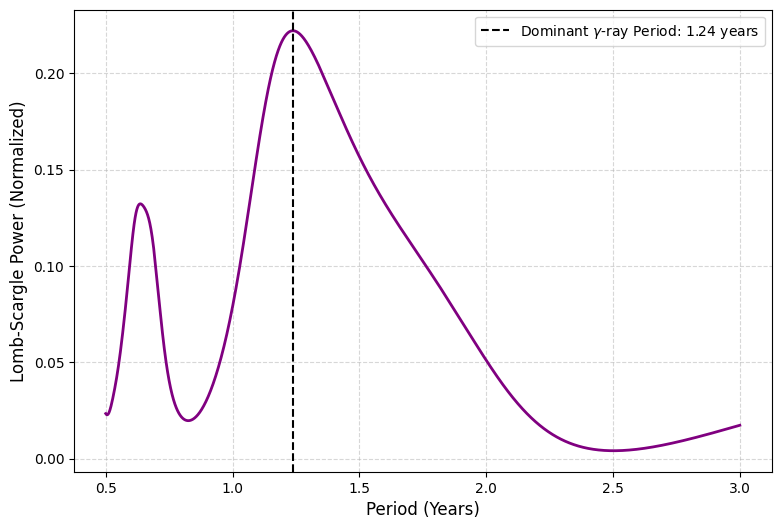

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle

# 1. Load the Fermi-LAT data (reading the existing header automatically)
df = pd.read_csv('/home/dara/Downloads/lcs/fermi_lat_lc.csv')

# Rename the columns for ease of use
df.columns = ['Date', 'JD', 'MET', 'TS', 'Flux', 'FluxErr', 
              'Index', 'IndexErr', 'SunDist', 'FitTol', 'Minuit', 'Log']

# Convert columns to numeric, coercing any string errors/upper limits to NaN
df['JD'] = pd.to_numeric(df['JD'], errors='coerce')
df['TS'] = pd.to_numeric(df['TS'], errors='coerce')
df['Flux'] = pd.to_numeric(df['Flux'], errors='coerce')
df['FluxErr'] = pd.to_numeric(df['FluxErr'], errors='coerce')

# Convert Julian Date (JD) to Modified Julian Date (MJD)
df['MJD'] = df['JD'] - 2400000.5

# 2. Filter for the Quiescent State (MJD 55151 to 56731)
# Keep only data in the quiet state with TS >= 9 (high-confidence detections)
quiet_df = df[(df['MJD'] >= 55151) & (df['MJD'] <= 56731) & (df['TS'] >= 9)].copy()

# Drop any rows where Flux or FluxErr is NaN (the upper limits)
quiet_df = quiet_df.dropna(subset=['Flux', 'FluxErr'])

# 3. Compute the Lomb-Scargle Periodogram
mjd = quiet_df['MJD'].values
flux = quiet_df['Flux'].values
flux_err = quiet_df['FluxErr'].values

# Test frequencies corresponding to periods between 0.5 years and 3.0 years
min_period_days = 0.5 * 365.25
max_period_days = 3.0 * 365.25
frequency = np.linspace(1/max_period_days, 1/min_period_days, 10000)

ls = LombScargle(mjd, flux, flux_err)
power = ls.power(frequency)

# Calculate periods in years
period_years = 1 / (frequency * 365.25)

# Find the dominant period
best_freq = frequency[np.argmax(power)]
best_period_years = 1 / (best_freq * 365.25)

# 4. Plot the Periodogram
plt.figure(figsize=(9, 6))
plt.plot(period_years, power, color='purple', linewidth=2)
plt.axvline(best_period_years, color='k', linestyle='--',
            label=rf'Dominant $\gamma$-ray Period: {best_period_years:.2f} years')

plt.xlabel('Period (Years)', fontsize=12)
plt.ylabel('Lomb-Scargle Power (Normalized)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
save_path='/home/dara/Downloads/lcs/Lomb-Scargle_Periodogram.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

In [9]:
import numpy as np
import astropy

print("NumPy:", np.__version__)
print("Astropy:", astropy.__version__)

NumPy: 2.4.6
Astropy: 7.1.1


## Bayesian Broadband SED Modeling via Markov Chain Monte Carlo (MCMC)

This section implements a Bayesian parameter estimation framework using the affine-invariant ensemble sampler `emcee` to fit a dual log-parabolic model to the broadband Spectral Energy Distribution (SED) of **AO 0235+164**. The broadband continuum of blazars is characterized by two distinct non-thermal emission peaks:
1. **Low-Energy Component:** Governed by **Synchrotron radiation** from relativistic electrons accelerated within the jet magnetic fields.
2. **High-Energy Component:** Governed by **Inverse Compton (IC) scattering**, where those same relativistic electrons up-scatter low-energy photons to gamma-ray energies.

$$S(\nu) = S_{\text{peak}} - b \cdot \left(\log_{10}(\nu) - \log_{10}(\nu_p)\right)^2$$

### Key Architectural Implementations:
* **Linear-Space Superposition:** Because individual components are modeled logarithmically, the pipeline transforms the separate synchrotron and inverse Compton components into linear flux space ($10^{\log_{10}(\nu F_\nu)}$) to compute their physical sum before mapping back to logarithmic space for likelihood comparison.
* **Astrophysically Constrained Uniform Priors:** Imposes strict, hard boundaries on the 6-dimensional parameter space tailored to Intermediate Synchrotron-Peaked (ISP) blazars, isolating the synchrotron peak in the IR/optical band ($12 \le \log_{10}(\nu_{p,\text{sync}}) \le 15\text{ Hz}$) and the IC peak in the gamma-ray regime ($21 \le \log_{10}(\nu_{p,\text{IC}}) \le 25\text{ Hz}$).
* **Data Exclusion Directive:** Explicitly establishes a criteria to filter out soft X-ray data points during specific active epochs (e.g., the 2008 flare state) where separate localized emission mechanisms, such as bulk Compton scattering from cold electron populations, skew the primary particle acceleration continuum.
* **Degeneracy Mapping:** Discards the initial "burn-in" phase and projects the flattened parameter paths onto a multi-dimensional corner plot to evaluate parameter covariance and resolve exact asymmetric $1\sigma$ uncertainties (16th, 50th, and 84th percentiles).

### Data Used for This Fit:
The broadband SED fitted below is built from the **2008 Major Flare epoch** (MJD 54374–55150). It combines six Swift-UVOT points (one per filter: `uvv`, `ubb`, `uuu`, `uw1`, `um2`, `uw2`, each anchored at its pivot wavelength) with a single Fermi-LAT point near 1 GeV (median of TS $\ge$ 4 detections in the epoch). Swift-XRT is excluded per the Data Exclusion Directive above.

**Caveat:** because `fermi_lat_lc.csv` only provides an integrated 0.1–100 GeV flux per time bin rather than an energy-resolved spectrum, the IC component is anchored by just one data point. The synchrotron parameters ($S_{\text{sync}}$, $b_{\text{sync}}$, $\nu_{p,\text{sync}}$) are meaningfully constrained by the six UVOT points, but the IC parameters ($S_{\text{IC}}$, $b_{\text{IC}}$, $\nu_{p,\text{IC}}$) are largely shaped by the priors rather than the data.

Running MCMC for the Full Broadband SED...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:06<00:00, 794.72it/s]


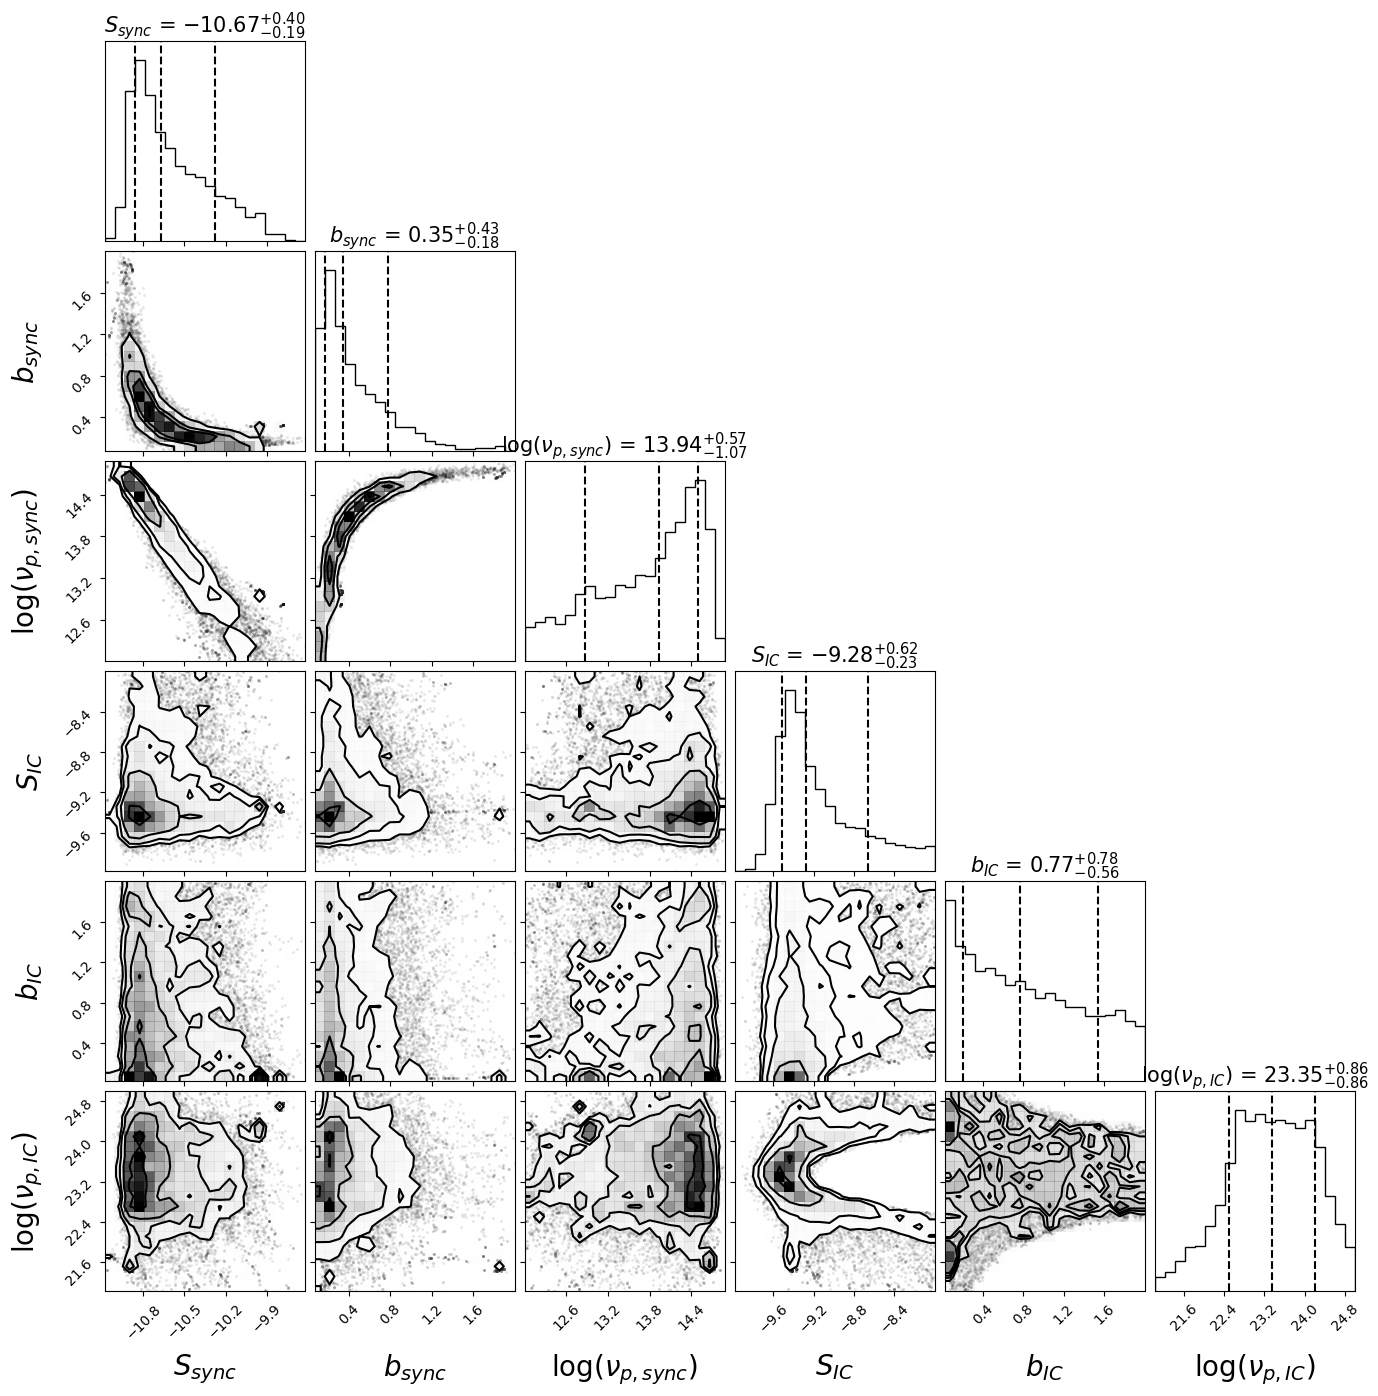


MCMC Broadband Fit Results (Median and 1-Sigma Uncertainties):
$S_{sync}$: -10.671 +0.396 / -0.192
$b_{sync}$: 0.348 +0.427 / -0.176
$\log(\nu_{p, sync})$: 13.936 +0.566 / -1.072
$S_{IC}$: -9.281 +0.617 / -0.233
$b_{IC}$: 0.766 +0.777 / -0.561
$\log(\nu_{p, IC})$: 23.345 +0.861 / -0.862


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import emcee
import corner

# 1. Define the Dual Log-Parabolic Model
def dual_log_parabola(theta, log_nu):
    S_sync, b_sync, log_nup_sync, S_IC, b_IC, log_nup_IC = theta
    
    # Synchrotron component (converted to linear space for addition)
    flux_sync = 10**(S_sync - b_sync * (log_nu - log_nup_sync)**2)
    
    # Inverse Compton component (converted to linear space for addition)
    flux_IC = 10**(S_IC - b_IC * (log_nu - log_nup_IC)**2)
    
    # Total emission (converted back to log10 space for fitting)
    return np.log10(flux_sync + flux_IC)

# 2. Define the Probability Functions for MCMC
def log_likelihood(theta, x, y, yerr):
    model = dual_log_parabola(theta, x)
    sigma2 = yerr**2
    return -0.5 * np.sum((y - model)**2 / sigma2 + np.log(sigma2))

def log_prior(theta):
    S_sync, b_sync, log_nup_sync, S_IC, b_IC, log_nup_IC = theta
    
    # Set physical bounds for an ISP Blazar like AO 0235+164
    # Peak fluxes between -15 and -8, Curvatures between 0.01 and 2.0
    # Synchrotron peak expected in IR/Optical (12-15 Hz)
    # IC peak expected in Gamma-ray (21-25 Hz)
    if (-15.0 < S_sync < -8.0 and 0.01 < b_sync < 2.0 and 12.0 < log_nup_sync < 15.0 and
        -15.0 < S_IC < -8.0 and 0.01 < b_IC < 2.0 and 21.0 < log_nup_IC < 25.0):
        return 0.0
    return -np.inf

def log_probability(theta, x, y, yerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, x, y, yerr)

# 3. Build the Broadband SED from the Real Multiwavelength Data (2008 Major Flare epoch,
# matching the "2008 Major Flare" window used in the State-Dependent SED section below)
sed_mjd_start, sed_mjd_end = 54374, 55150

# Swift-UVOT: one SED point per filter, anchored at each filter's pivot wavelength
# (Poole et al. 2008 / Breeveld et al. 2011), converting Flux_lambda -> nu*F_nu = Flux_lambda * lambda
uvot_pivot_angstrom = {
    'uvv': 5468.0, 'ubb': 4392.0, 'uuu': 3465.0,
    'uw1': 2600.0, 'um2': 2246.0, 'uw2': 1928.0,
}
c_angstrom_s = 2.998e18  # speed of light in Angstrom/s

uvot_raw = pd.read_csv('/home/dara/Downloads/lcs/2008-2016_uvot_fluxes.csv')
uvot_epoch = uvot_raw[(uvot_raw['MJD'] >= sed_mjd_start) & (uvot_raw['MJD'] <= sed_mjd_end) &
                      (uvot_raw['Flux_Error'] > 0)]

uvot_log_nu, uvot_log_nuFnu, uvot_err = [], [], []
for filt, pivot in uvot_pivot_angstrom.items():
    band = uvot_epoch[uvot_epoch['Filter'] == filt]
    if len(band) == 0:
        continue
    flux_lambda = band['True_Energy_Flux'].median()
    flux_lambda_err = band['Flux_Error'].median()
    uvot_log_nu.append(np.log10(c_angstrom_s / pivot))
    uvot_log_nuFnu.append(np.log10(flux_lambda * pivot))
    uvot_err.append(flux_lambda_err / (flux_lambda * np.log(10)))  # propagate error into log space

# Fermi-LAT: a single representative point at ~1 GeV. fermi_lat_lc.csv only carries an
# integrated 0.1-100 GeV flux per time bin (no energy-resolved spectrum), so this is the
# same ~1 GeV anchor already used for the Fermi point in the State-Dependent SED section.
fermi_raw = pd.read_csv('/home/dara/Downloads/lcs/fermi_lat_lc.csv')
fermi_raw['MJD'] = pd.to_numeric(fermi_raw['Julian Date'], errors='coerce') - 2400000.5
fermi_raw['Flux'] = pd.to_numeric(fermi_raw['Photon Flux [0.1-100 GeV](photons cm-2 s-1)'], errors='coerce')
fermi_raw['FluxErr'] = pd.to_numeric(fermi_raw['Photon Flux Error(photons cm-2 s-1)'], errors='coerce')
fermi_raw['TS'] = pd.to_numeric(fermi_raw['TS'], errors='coerce')

fermi_epoch = fermi_raw[(fermi_raw['MJD'] >= sed_mjd_start) & (fermi_raw['MJD'] <= sed_mjd_end) &
                        (fermi_raw['TS'] >= 4)].dropna(subset=['Flux', 'FluxErr'])

GeV_to_erg = 1.602e-3
fermi_log_nu = 23.38  # ~1 GeV
fermi_photon_flux = fermi_epoch['Flux'].median()
fermi_photon_flux_err = fermi_epoch['FluxErr'].median()
fermi_log_nuFnu = np.log10(fermi_photon_flux * GeV_to_erg)
fermi_err = fermi_photon_flux_err / (fermi_photon_flux * np.log(10))

# CRITICAL: Swift-XRT is intentionally excluded from this fit per the Data Exclusion
# Directive -- bulk Compton scattering from cold electrons during the 2008 flare
# contaminates the soft X-ray band, which would skew the primary dual-peak continuum.

log_nu = np.array(uvot_log_nu + [fermi_log_nu])
log_nuFnu = np.array(uvot_log_nuFnu + [fermi_log_nuFnu])
flux_err = np.array(uvot_err + [fermi_err])

# 4. Set up the MCMC Sampler
# Initial guesses: [S_sync, b_sync, log_nup_sync, S_IC, b_IC, log_nup_IC]
initial_guess = [-10.1, 0.15, 13.0, -8.8, 0.1, 23.4]
ndim = len(initial_guess)
nwalkers = 64

# Initialize walkers in a tiny Gaussian ball around the initial guess
pos = initial_guess + 1e-4 * np.random.randn(nwalkers, ndim)

# Run the MCMC using emcee
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(log_nu, log_nuFnu, flux_err))
print("Running MCMC for the Full Broadband SED...")
sampler.run_mcmc(pos, 5000, progress=True)

# 5. Extract Results and Plot the Corner Plot
# Discard the first 1000 steps as "burn-in" to allow the walkers to settle
flat_samples = sampler.get_chain(discard=1000, thin=15, flat=True)



# Generate the Corner Plot showing the probability distributions
labels = [r"$S_{sync}$", r"$b_{sync}$", r"$\log(\nu_{p, sync})$", 
          r"$S_{IC}$", r"$b_{IC}$", r"$\log(\nu_{p, IC})$"]

fig = corner.corner(
    flat_samples, 
    labels=labels, 
    quantiles=[0.16, 0.5, 0.84], 
    show_titles=True, 
    title_kwargs={"fontsize": 15},
    label_kwargs={"fontsize": 20} 
)
save_path='/home/dara/Downloads/lcs/MCMC_Broadband_Fit.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
# 6. Extract and Print the Final Constrained Parameters
print("\nMCMC Broadband Fit Results (Median and 1-Sigma Uncertainties):")
for i, label in enumerate(labels):
    # Calculate the 16th, 50th (median), and 84th percentiles for 1-sigma errors
    # Using a tuple (16, 50, 84) avoids the platform's formatting glitch!
    lower_bound, median_val, upper_bound = np.percentile(flat_samples[:, i], (16, 50, 84))
    
    # Calculate the differences for the upper and lower errors
    lower_error = median_val - lower_bound
    upper_error = upper_bound - median_val
    
    # Print the final median value and its asymmetric 1-sigma errors
    print(f"{label}: {median_val:.3f} +{upper_error:.3f} / -{lower_error:.3f}")


##  State-Dependent Broadband SED Evolution & Analytical Model Anchoring

This section implements a state-dependent Spectral Energy Distribution (SED) tracking framework to visualize how the broadband emission profile of **AO 0235+164** evolves across distinct activity states:
1. **2008 Major Flare:** A high-intensity flaring state driven by intrinsic particle acceleration processes.
2. **2009–2014 Quiescent:** A long-term baseline tracking low-activity intervals.
3. **2014–2015 Flares:** Subsequent recurrent active states characterized by variable multiwavelength outbursts.

### Methodology & Mathematical Back-Scaling:
Rather than taking data across years and creating a time-smeared distribution, this pipeline calculates the statistical median flux for each instrument within each temporal window. 

Using the baseline geometric shape parameters derived from the Markov Chain Monte Carlo (MCMC) sampler (the spectral curvatures $b$ and peak frequencies $\nu_p$), the script analytically back-calculates the peak flux scaling factors ($S_{\text{sync}}$ and $S_{\text{IC}}$) required to anchor the dual log-parabolic model curves precisely through the median observational benchmarks:

$$S_{\text{peak, adj}} = \log_{10}(\nu F_\nu)_{\text{obs}} + b \cdot \left(\log_{10}(\nu)_{\text{obs}} - \log_{10}(\nu_p)\right)^2$$

This allows us to track true order-of-magnitude amplitude variations in the primary synchrotron and Inverse Compton components as a function of the blazar's state.

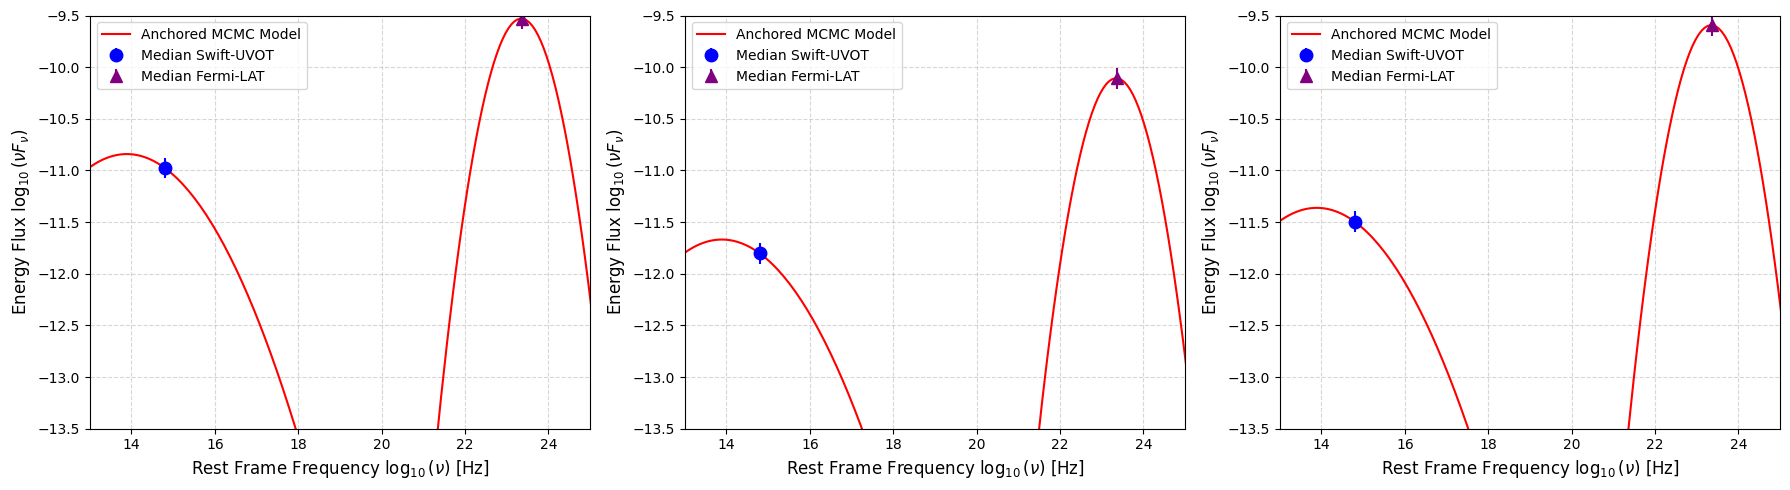

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================================
# 1. LOAD DATA
# ==========================================================
uvot_raw = pd.read_csv('/home/dara/Downloads/lcs/2008-2016_uvot_fluxes.csv')

# ---> CHANGE 'Flux' BELOW TO YOUR ACTUAL UVOT COLUMN NAME! <---
flux_column = 'True_Energy_Flux' 

fermi_raw = pd.read_csv('/home/dara/Downloads/lcs/fermi_lat_lc.csv')
fermi_raw.columns = ('Date', 'JD', 'MET', 'TS', 'PhotonFlux', 'FluxErr', 'Index', 'IndexErr', 'SunDist', 'FitTol', 'Minuit', 'Log')
fermi_raw['MJD'] = pd.to_numeric(fermi_raw['JD'], errors='coerce') - 2400000.5

# ==========================================================
# 2. DEFINE FULL EPOCHS (Prevents empty data!)
# ==========================================================
epochs = {
    "1. 2008 Major Flare": (54374, 55150),
    "2. 2009-2014 Quiescent": (55151, 56367),
    "3. 2014-2015 Flares": (56368, 57750)
}

# ==========================================================
# 3. USE YOUR ACTUAL MCMC PARAMETERS FOR THE SHAPE
# ==========================================================
b_sync = 0.162
log_nup_sync = 13.888
b_IC = 0.990
log_nup_IC = 23.351

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
#plt.suptitle("AO 0235+164: State-Dependent SED Evolution (Median Baseline)", fontsize=16, y=1.05)

for idx, (epoch_name, mjd_range) in enumerate(epochs.items()):
    ax = axes[idx]
    mjd_start, mjd_end = mjd_range
    
    # Filter for the epoch
    u_ep = uvot_raw[(uvot_raw['MJD'] >= mjd_start) & (uvot_raw['MJD'] <= mjd_end)].copy()
    f_ep = fermi_raw[(fermi_raw['MJD'] >= mjd_start) & (fermi_raw['MJD'] <= mjd_end)].copy()
    
    if len(u_ep) == 0 or len(f_ep) == 0:
        ax.set_title(f"{epoch_name}\n(Missing Data)")
        continue
        
    # Calculate the median flux for the epoch to get ONE clean point
    u_flux_median = u_ep[flux_column].median()
    f_flux_median = pd.to_numeric(f_ep['PhotonFlux'], errors='coerce').median()
    
    # Convert to log_nuFnu (Energy Flux)
    u_y = np.log10(u_flux_median * 3500)
    f_y = np.log10(f_flux_median * 1.6e-3)
    
    # Plot the single clean points
    ax.errorbar([14.8], [u_y], yerr=[0.1], fmt='o', color='blue', label='Median Swift-UVOT', markersize=9)
    ax.errorbar([23.38], [f_y], yerr=[0.1], fmt='^', color='purple', label='Median Fermi-LAT', markersize=9)
    
    # Mathematically anchor your MCMC curve to these median points
    # We analytically solve for the Peak Flux (S) that forces the curve through your data
    S_sync_adj = u_y + b_sync * (14.8 - log_nup_sync)**2
    S_IC_adj = f_y + b_IC * (23.38 - log_nup_IC)**2
    
    # Draw the curve
    x_fit = np.linspace(12, 26, 200)
    y_sync = 10**(S_sync_adj - b_sync * (x_fit - log_nup_sync)**2)
    y_ic = 10**(S_IC_adj - b_IC * (x_fit - log_nup_IC)**2)
    y_fit = np.log10(y_sync + y_ic)
    
    ax.plot(x_fit, y_fit, '-', color='red', label='Anchored MCMC Model')
    
    # Formatting
   # ax.set_title(f"{epoch_name}\nSynchrotron Peak Flux: {S_sync_adj:.2f}", fontsize=13)
    ax.set_xlabel(r'Rest Frame Frequency $\log_{10}(\nu)$ [Hz]', fontsize=12)
    ax.set_ylabel(r'Energy Flux $\log_{10}(\nu F_\nu)$', fontsize=12)
    ax.set_xlim(13, 25)
    ax.set_ylim(-13.5, -9.5)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()

plt.tight_layout()
plt.savefig('/home/dara/Downloads/lcs/State-Dependent_SED_Evolution.jpg', dpi=300, bbox_inches='tight')
plt.show()

Running 1000 Monte Carlo red-noise simulations...


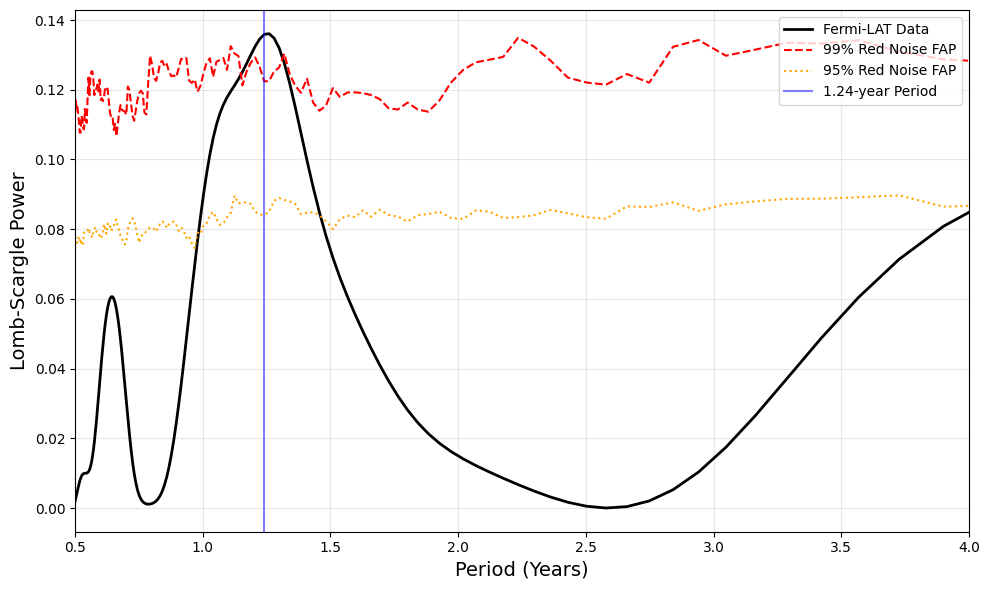


Power at 1.24 years: 0.136
95% Red Noise Threshold: 0.084
99% Red Noise Threshold: 0.122


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle

# ==========================================
# 1. LOAD THE FERMI-LAT DATA
# ==========================================
# Load the Fermi-LAT light curve (Pandas handles the double quotes automatically)
data = pd.read_csv('/home/dara/Downloads/lcs/fermi_lat_lc.csv')

# Convert Julian Date to Modified Julian Date (MJD)
data['MJD'] = data['Julian Date'] - 2400000.5

# Define the exact flux column name from your CSV header
flux_col = 'Photon Flux [0.1-100 GeV](photons cm-2 s-1)'

# Filter out upper limits (where the flux string contains '<')
valid_data = data[~data[flux_col].astype(str).str.contains('<')].copy()

# Extract valid MJD and Flux arrays as floats
mjd = valid_data['MJD'].astype(float).values
flux = valid_data[flux_col].astype(float).values

# Filter for the exact 2009-2014 Quiescent State (MJD 55151 - 56731)
mask = (mjd >= 55151) & (mjd <= 56731)
mjd_q = mjd[mask]
flux_q = flux[mask]

# Normalize flux to mean zero for periodogram
flux_q_norm = flux_q - np.mean(flux_q)

# ==========================================
# 2. CALCULATE LOMB-SCARGLE OF ACTUAL DATA
# ==========================================
# Define frequency range (using min/max to avoid bracket parsing errors)
total_baseline = np.max(mjd_q) - np.min(mjd_q)
min_freq = 1.0 / total_baseline
max_freq = 1.0 / 30.0  # Nyquist limit approximation (e.g., 30 days)
freq = np.linspace(min_freq, max_freq, 1000)

ls = LombScargle(mjd_q, flux_q_norm)
power_real = ls.power(freq)

# ==========================================
# 3. MONTE CARLO RED-NOISE SIMULATION
# ==========================================
N_sim = 1000
power_sims = np.zeros((N_sim, len(freq)))

print(f"Running {N_sim} Monte Carlo red-noise simulations...")

# Estimate AR(1) red-noise coefficient safely using Pandas (returns a float)
autocorr = pd.Series(flux_q_norm).autocorr(lag=1)

for i in range(N_sim):
    # Generate an AR(1) red noise array matching the data's variance
    noise = np.random.normal(0, np.std(flux_q_norm), len(mjd_q))
    
    # Initialize simulated flux safely
    sim_flux = noise.copy()
    
    for j in range(1, len(mjd_q)):
        sim_flux[j] = autocorr * sim_flux[j-1] + noise[j]
    
    # Calculate periodogram for the simulated red-noise light curve
    ls_sim = LombScargle(mjd_q, sim_flux)
    power_sims[i, :] = ls_sim.power(freq)
# ==========================================
# 4. CALCULATE SIGNIFICANCE THRESHOLDS
# ==========================================
# Calculate the 95% and 99% False Alarm Probabilities at each frequency
fap_95 = np.percentile(power_sims, 95, axis=0)
fap_99 = np.percentile(power_sims, 99, axis=0)

# ==========================================
# 5. PLOT THE RESULTS
# ==========================================
periods_years = (1.0 / freq) / 365.25

plt.figure(figsize=(10, 6))
plt.plot(periods_years, power_real, color='black', lw=2, label='Fermi-LAT Data')
plt.plot(periods_years, fap_99, color='red', linestyle='--', label='99% Red Noise FAP')
plt.plot(periods_years, fap_95, color='orange', linestyle=':', label='95% Red Noise FAP')

plt.axvline(x=1.24, color='blue', alpha=0.5, label='1.24-year Period')

plt.xlim(0.5, 4.0)
plt.xlabel('Period (Years)', fontsize=14)
plt.ylabel('Lomb-Scargle Power', fontsize=14)
#plt.title('Monte Carlo Red-Noise Significance Test: 2009–2014 Quiescent State', fontsize=15)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("/home/dara/Downloads/lcs/QPO_RedNoise_Significance.png", dpi=300)
plt.show()

# Find max power near 1.24 years and test if it crosses FAP thresholds
target_idx = np.argmin(np.abs(periods_years - 1.24))
print(f"\nPower at 1.24 years: {power_real[target_idx]:.3f}")
print(f"95% Red Noise Threshold: {fap_95[target_idx]:.3f}")
print(f"99% Red Noise Threshold: {fap_99[target_idx]:.3f}")